In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Лабораторная работа №3: Понижение размерности
## Задание 1. Геометрия данных в пространстве признаков
### 1.1.

In [11]:
df = pd.read_csv('../data/weatherAUS.csv')
print(f"Исходный размер датасета: {df.shape}")
print(f"\nПервые 5 строк:")
print(df.head())

numeric_df = df.select_dtypes(include=[np.number])
print(f"\nЧисло числовых признаков: {numeric_df.shape[1]}")
print(f"Признаки: {list(numeric_df.columns)}")

X = numeric_df.dropna()
print(f"\nОбъектов после удаления пропусков: {X.shape[0]}")

Исходный размер датасета: (145460, 23)

Первые 5 строк:
         Date Location  MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  \
0  2008-12-01   Albury     13.4     22.9       0.6          NaN       NaN   
1  2008-12-02   Albury      7.4     25.1       0.0          NaN       NaN   
2  2008-12-03   Albury     12.9     25.7       0.0          NaN       NaN   
3  2008-12-04   Albury      9.2     28.0       0.0          NaN       NaN   
4  2008-12-05   Albury     17.5     32.3       1.0          NaN       NaN   

  WindGustDir  WindGustSpeed WindDir9am  ... Humidity9am  Humidity3pm  \
0           W           44.0          W  ...        71.0         22.0   
1         WNW           44.0        NNW  ...        44.0         25.0   
2         WSW           46.0          W  ...        38.0         30.0   
3          NE           24.0         SE  ...        45.0         16.0   
4           W           41.0        ENE  ...        82.0         33.0   

   Pressure9am  Pressure3pm  Cloud9am  Clo

### 1.2.

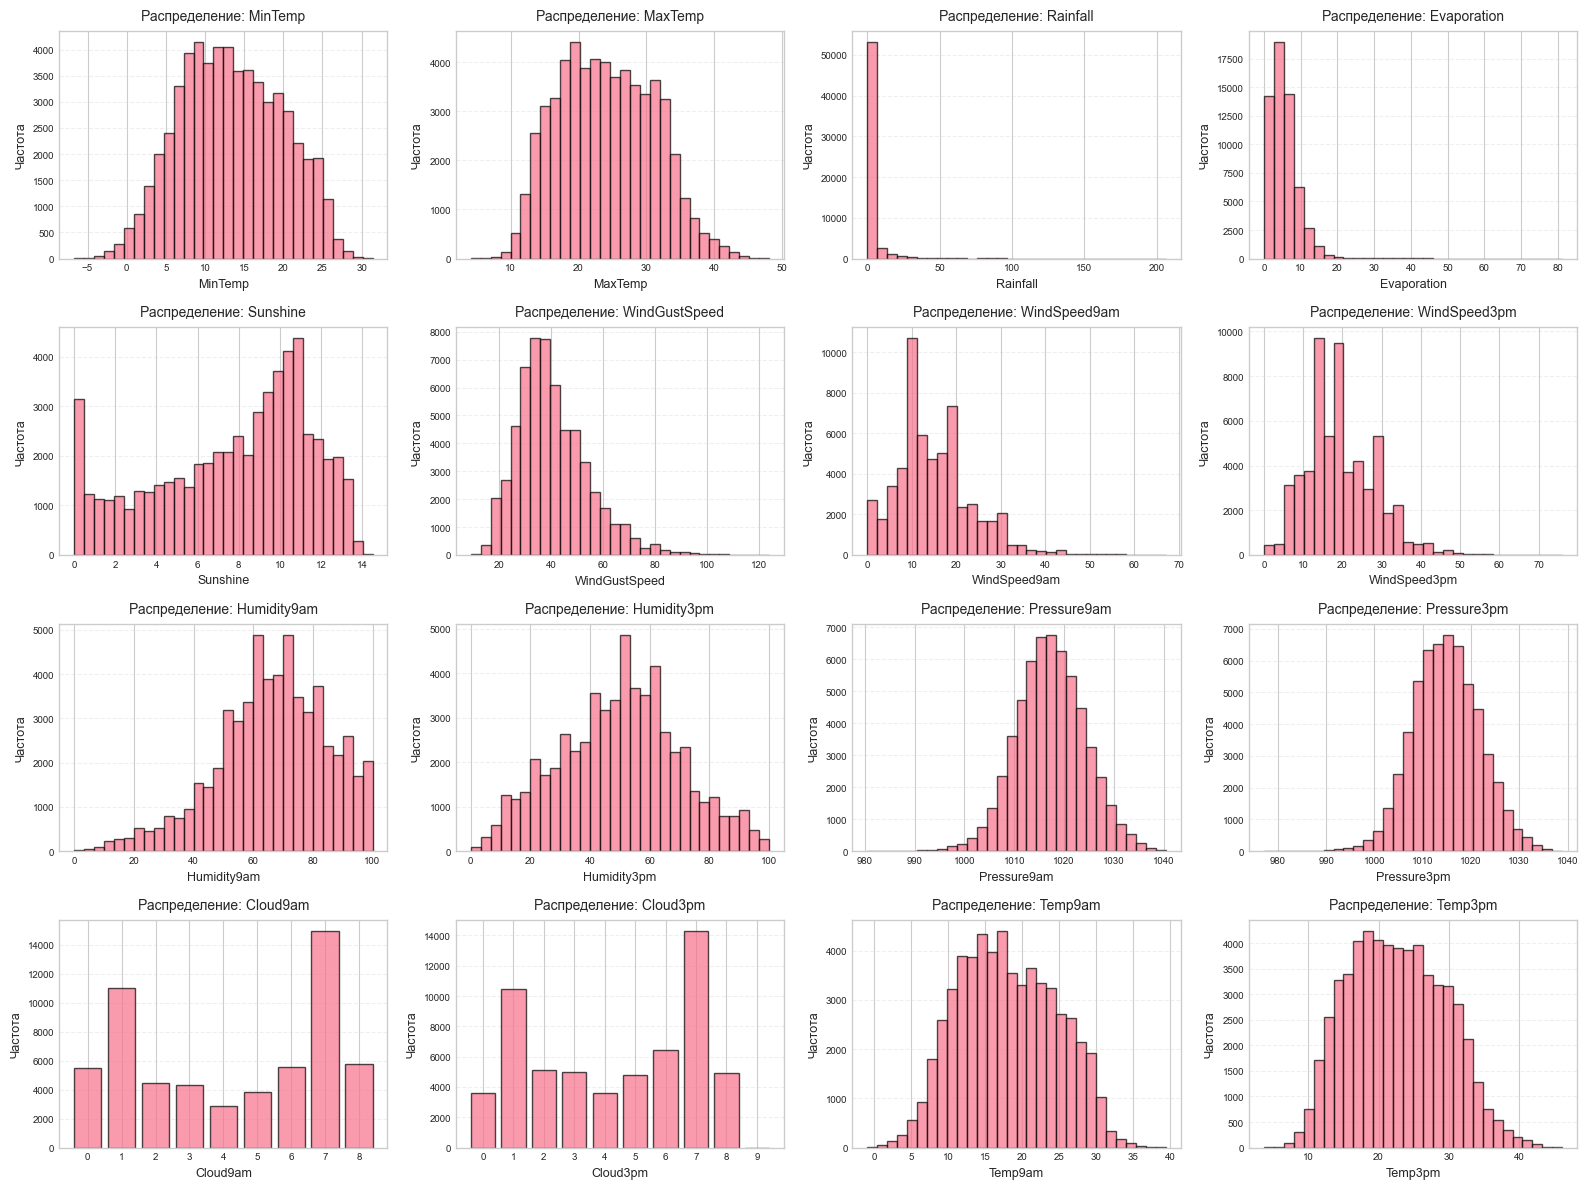

In [12]:
discrete_features = ['Cloud9am', 'Cloud3pm']

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.ravel()

for idx, col in enumerate(X.columns[:16]):
    ax = axes[idx]
    data = X[col].dropna()

    if col in discrete_features:
        value_counts = data.value_counts().sort_index()
        ax.bar(value_counts.index, value_counts.values, edgecolor='black', alpha=0.7)
        ax.set_xticks(value_counts.index)
        ax.set_xlabel(col, fontsize=9)
    else:
        ax.hist(data, bins=30, edgecolor='black', alpha=0.7)
        ax.set_xlabel(col, fontsize=9)

    ax.set_ylabel('Частота', fontsize=9)
    ax.set_title(f'Распределение: {col}', fontsize=10, pad=8)
    ax.tick_params(axis='both', labelsize=7)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

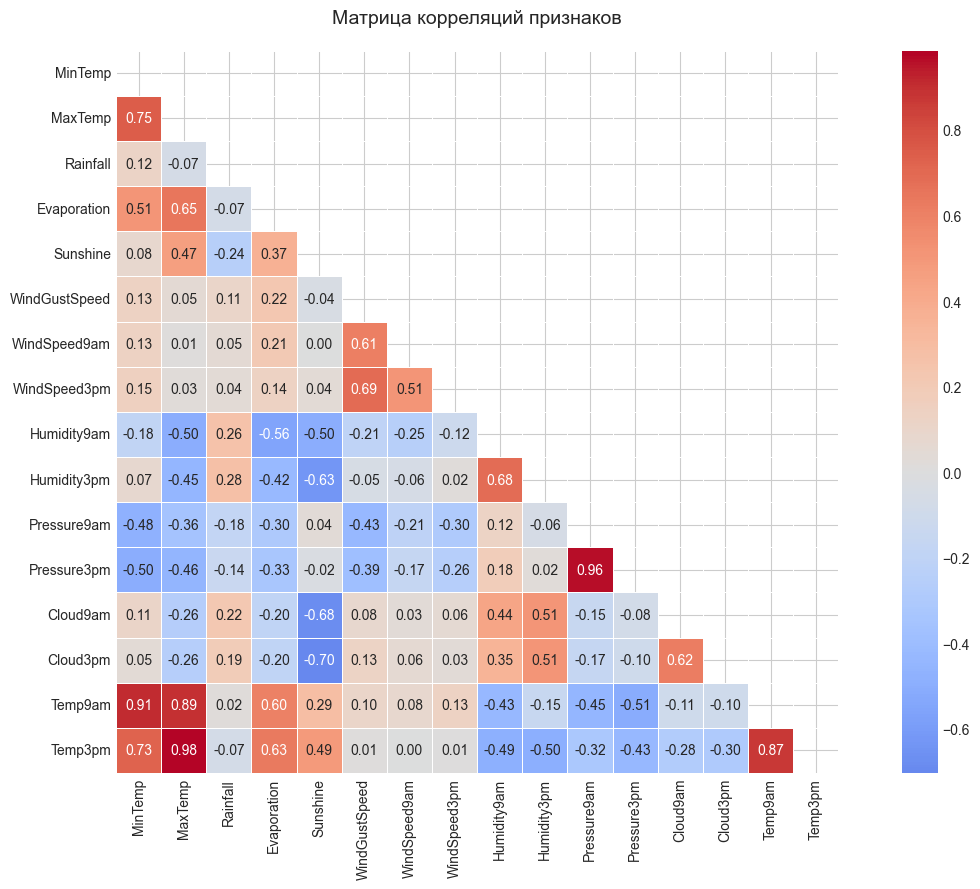

In [13]:
plt.figure(figsize=(13, 9))
corr_matrix = X.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Матрица корреляций признаков', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

### 1.3.
Есть сильно коррелированные признаки (пары с |r| > 0.8):
- MaxTemp и Temp3pm (0.98)
- Pressure9am и Pressure3pm (0.96)
- MinTemp и Temp9am (0.91)
- MaxTemp и Temp9am (0.89)
- Temp9am и Temp3pm (0.87)

Можно ли предположить, что часть признаков содержит избыточную информацию?
Да. Признаки, измеряющие один и тот же параметр в разное время суток (утро/день), сильно коррелируют между собой:
- температуры (MinTemp, MaxTemp, Temp9am, Temp3pm)
- давление (Pressure9am, Pressure3pm)
- облачность (Cloud9am, Cloud3pm)
Эти признаки дублируют информацию и могут быть сокращены без существенной потери данных.

## Задание 2. Реализация PCA


Объектов: 58236
Признаков: 16

Сравнение с sklearn:
  PC1 корреляция: 1.000000
  PC2 корреляция: 1.000000

Вклад компонент в дисперсию:
  Компонента 1: 34.80% (суммарно: 34.80%)
  Компонента 2: 21.31% (суммарно: 56.11%)
  Компонента 3: 13.35% (суммарно: 69.47%)
  Компонента 4: 6.36% (суммарно: 75.82%)
  Компонента 5: 5.64% (суммарно: 81.46%)
  Компонента 6: 4.65% (суммарно: 86.11%)
  Компонента 7: 3.00% (суммарно: 89.11%)
  Компонента 8: 2.58% (суммарно: 91.69%)
  Компонента 9: 2.45% (суммарно: 94.13%)
  Компонента 10: 1.94% (суммарно: 96.08%)
  Компонента 11: 1.61% (суммарно: 97.69%)
  Компонента 12: 1.34% (суммарно: 99.03%)
  Компонента 13: 0.57% (суммарно: 99.60%)
  Компонента 14: 0.18% (суммарно: 99.79%)
  Компонента 15: 0.15% (суммарно: 99.94%)
  Компонента 16: 0.06% (суммарно: 100.00%)


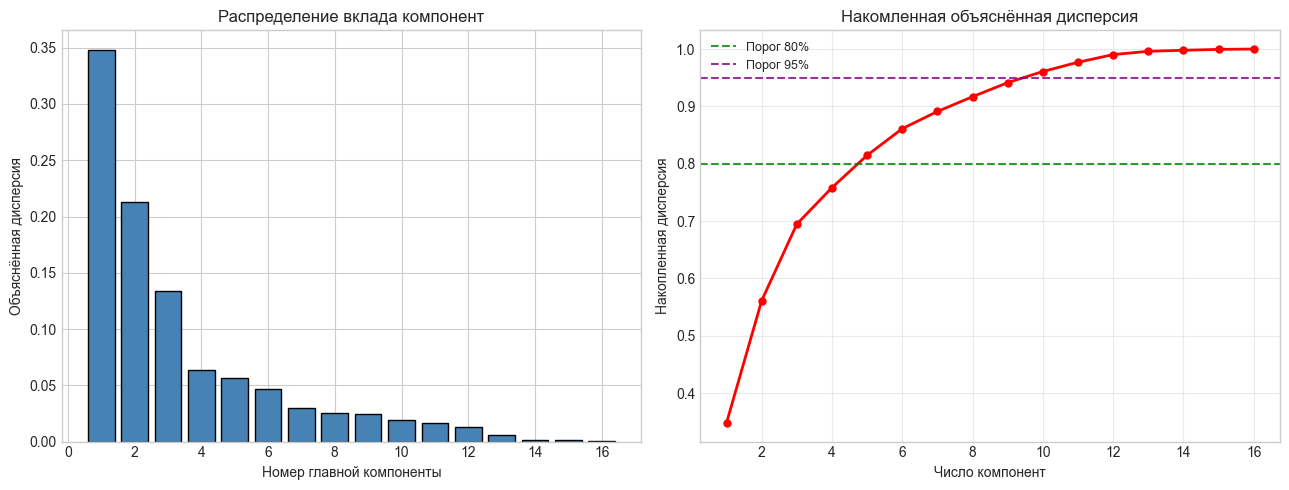


► Для 80% дисперсии достаточно 5 компонент (81.5%)
► Для 95% дисперсии требуется 10 компонент (96.1%)


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

X_std = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

cov_mat = np.cov(X_std, rowvar=False)
eig_vals, eig_vecs = np.linalg.eigh(cov_mat)

sort_idx = np.argsort(eig_vals)[::-1]
eig_vals = eig_vals[sort_idx]
eig_vecs = eig_vecs[:, sort_idx]

var_ratio = eig_vals / eig_vals.sum()
var_cumsum = np.cumsum(var_ratio)

def project_pca(data, vectors, n_comp):
    return np.dot(data, vectors[:, :n_comp])

print(f"\nОбъектов: {X.shape[0]}")
print(f"Признаков: {X.shape[1]}")

X_our_proj = project_pca(X_std, eig_vecs, 2)

print("\nСравнение с sklearn:")
pca_ref = PCA()
X_transformed_ref = pca_ref.fit_transform(X_std)

c1 = np.corrcoef(X_our_proj[:, 0], X_transformed_ref[:, 0])[0, 1]
c2 = np.corrcoef(X_our_proj[:, 1], X_transformed_ref[:, 1])[0, 1]
print(f"  PC1 корреляция: {np.abs(c1):.6f}")
print(f"  PC2 корреляция: {np.abs(c2):.6f}")

print("\nВклад компонент в дисперсию:")
for idx, (var, cum) in enumerate(zip(var_ratio, var_cumsum), start=1):
    print(f"  Компонента {idx}: {var*100:.2f}% (суммарно: {cum*100:.2f}%)")

fig, axs = plt.subplots(1, 2, figsize=(13, 5))

axs[0].bar(np.arange(1, len(var_ratio)+1), var_ratio, color='steelblue', edgecolor='black')
axs[0].set_xlabel('Номер главной компоненты')
axs[0].set_ylabel('Объяснённая дисперсия')
axs[0].set_title('Распределение вклада компонент')

axs[1].plot(np.arange(1, len(var_cumsum)+1), var_cumsum, 'ro-', linewidth=2, markersize=5)
axs[1].axhline(0.80, color='green', ls='--', alpha=0.8, label='Порог 80%')
axs[1].axhline(0.95, color='purple', ls='--', alpha=0.8, label='Порог 95%')
axs[1].set_xlabel('Число компонент')
axs[1].set_ylabel('Накопленная дисперсия')
axs[1].set_title('Накомленная объяснённая дисперсия')
axs[1].legend(fontsize=9)
axs[1].grid(alpha=0.4)

plt.tight_layout()
plt.show()

k_80 = np.where(var_cumsum >= 0.80)[0][0] + 1
k_95 = np.where(var_cumsum >= 0.95)[0][0] + 1

print(f"\n► Для 80% дисперсии достаточно {k_80} компонент ({var_cumsum[k_80-1]*100:.1f}%)")
print(f"► Для 95% дисперсии требуется {k_95} компонент ({var_cumsum[k_95-1]*100:.1f}%)")

## Задание 3. Интерпретация главных компонент

In [46]:
features = X.columns.tolist()
loadings = pd.DataFrame(eig_vecs[:, :3], columns=['PC1', 'PC2', 'PC3'], index=features)

print("Коэффициенты признаков в главных компонентах")
print(loadings.round(3))

print("\nПризники с наибольшим вкладом в каждую компоненту:")
for pc in ['PC1', 'PC2', 'PC3']:
    print(f"\n{pc}:")
    top3 = loadings[pc].abs().sort_values(ascending=False).head(3)
    for idx in top3.index:
        print(f"- {idx}: {loadings.loc[idx, pc]:+.3f}")

print("\n1. Какие признаки больше всего влияют на первую компоненту?")
pc1_top5 = loadings['PC1'].abs().sort_values(ascending=False).head(5)
for feat, val in pc1_top5.items():
    print(f"- {feat}: {loadings.loc[feat, 'PC1']:+.3f}")

print("\n2. Можно ли интерпретировать первую компоненту как комбинацию признаков?")
print("Похоже, PC1 отражает общую погодную активность: давление, температура, влажность, ветер")

print("\n3. Есть ли признаки, которые практически не влияют на первые компоненты?")
loadings_subset = loadings.iloc[:, :3].abs()
total_influence = loadings_subset.sum(axis=1)
weakest = total_influence.idxmin()
print(f"   Признак с наименьшим влиянием: {weakest}")
print(f"   Его веса в первых трех компонентах:")
for i in range(3):
    val = loadings.loc[weakest, f'PC{i+1}']
    print(f"      PC{i+1}: {val:+.3f}")

Коэффициенты признаков в главных компонентах
                 PC1    PC2    PC3
MinTemp       -0.295  0.241 -0.263
MaxTemp       -0.389 -0.000 -0.207
Rainfall       0.046  0.225 -0.083
Evaporation   -0.323  0.010  0.023
Sunshine      -0.249 -0.327  0.119
WindGustSpeed -0.108  0.272  0.486
WindSpeed9am  -0.089  0.182  0.466
WindSpeed3pm  -0.090  0.224  0.453
Humidity9am    0.289  0.163 -0.209
Humidity3pm    0.233  0.311 -0.183
Pressure9am    0.206 -0.359 -0.025
Pressure3pm    0.238 -0.319  0.006
Cloud9am       0.161  0.358 -0.142
Cloud3pm       0.158  0.357 -0.108
Temp9am       -0.361  0.130 -0.232
Temp3pm       -0.385 -0.027 -0.210

Призники с наибольшим вкладом в каждую компоненту:

PC1:
- MaxTemp: -0.389
- Temp3pm: -0.385
- Temp9am: -0.361

PC2:
- Pressure9am: -0.359
- Cloud9am: +0.358
- Cloud3pm: +0.357

PC3:
- WindGustSpeed: +0.486
- WindSpeed9am: +0.466
- WindSpeed3pm: +0.453

1. Какие признаки больше всего влияют на первую компоненту?
- MaxTemp: -0.389
- Temp3pm: -0.385
- Temp9am

## Задание 4. Визуализация данных

Для сравнения выберем исходные признаки: 'Temp9am' и 'Temp3pm'


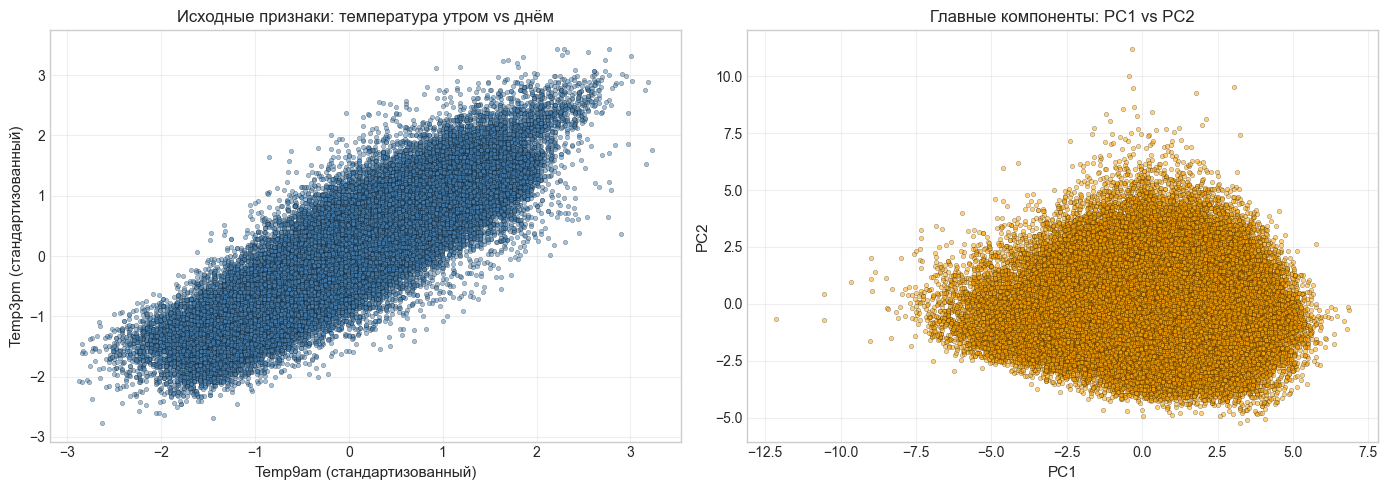

Доля объяснённой дисперсии
PC1: 34.80%
PC2: 21.31%
Суммарно первые 2 компоненты: 56.11%


In [16]:
X_std_array = X_std.values if hasattr(X_std, 'values') else X_std

X_pca = project_pca(X_std_array, eig_vecs, 2)

feat1_idx = list(X.columns).index('Temp9am')
feat2_idx = list(X.columns).index('Temp3pm')

print(f"Для сравнения выберем исходные признаки: 'Temp9am' и 'Temp3pm'")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(X_std_array[:, feat1_idx], X_std_array[:, feat2_idx], alpha=0.5, s=10, c='steelblue', edgecolors='black', linewidth=0.3)
ax1.set_xlabel('Temp9am (стандартизованный)', fontsize=11)
ax1.set_ylabel('Temp3pm (стандартизованный)', fontsize=11)
ax1.set_title('Исходные признаки: температура утром vs днём', fontsize=12)
ax1.grid(True, alpha=0.3)

ax2.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, s=10, c='orange', edgecolors='black', linewidth=0.3)
ax2.set_xlabel('PC1', fontsize=11)
ax2.set_ylabel('PC2', fontsize=11)
ax2.set_title('Главные компоненты: PC1 vs PC2', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Доля объяснённой дисперсии")
print(f"PC1: {var_ratio[0]*100:.2f}%")
print(f"PC2: {var_ratio[1]*100:.2f}%")
print(f"Суммарно первые 2 компоненты: {(var_ratio[0]+var_ratio[1])*100:.2f}%")

### Сравнение

Исходные признаки (Temp9am и Temp3pm):
- Точки вытянуты вдоль диагонали (температура утром и днём сильно коррелируют)
- Большинство объектов сконцентрировано в центре облака
- Есть выбросы (аномально холодные или жаркие дни)
- Трудно выделить группы или закономерности — данные сжаты в узкую полосу


Главные компоненты (PC1 и PC2):
- Данные развернуты — PC1 показывает общую погодную активность, PC2 — отклонения
- Облако точек более округлое и равномерно распределено
- Выбросы более заметны на периферии


### Ответы на вопросы

1. Улучшилась ли визуализация после PCA?
Да. В исходных признаках (Temp9am, Temp3pm) точки сжаты вдоль линии, так как признаки сильно коррелируют. PCA поворачивает оси так, чтобы максимизировать дисперсию — данные становятся более развернутыми и структура просматривается лучше.

2. Почему в пространстве главных компонент структура может быть заметнее?
- В пространстве главных компонент структура данных становится заметнее, потому что PC1 ориентирована вдоль направления максимальной дисперсии, а PC2 ортогональна ей и показывает второе по важности направление, из за этого корреляция между исходными признаками «размазывается» по новым осям, а избыточная информация уменьшается.



## Задание 5. Нелинейные методы снижения размерности

Взята выборка из 15000 объектов для ускорения


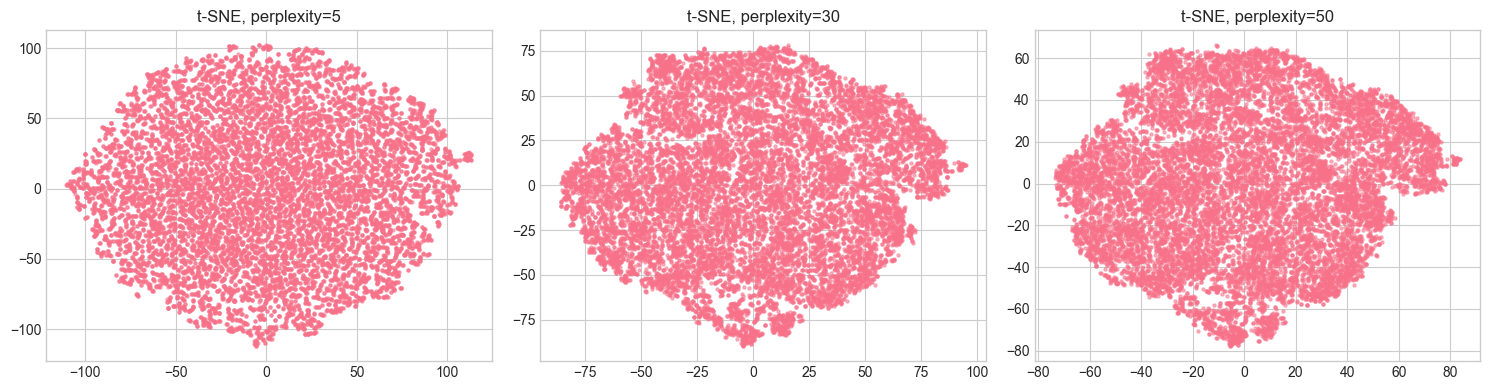

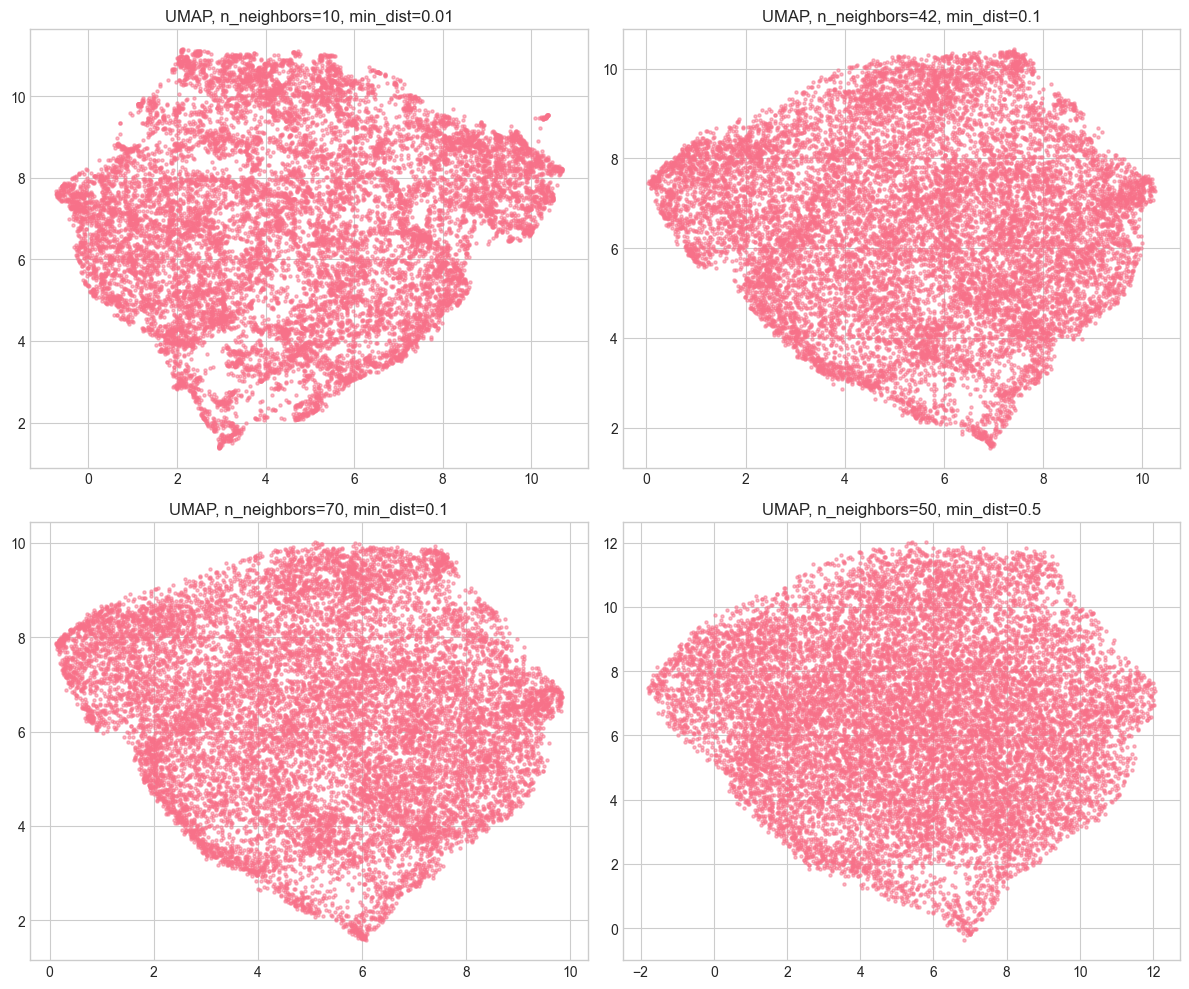

In [47]:
from sklearn.manifold import TSNE
import umap

np.random.seed(42)
sample_size = 15000
sample_idx = np.random.choice(X_std_array.shape[0], sample_size, replace=False)
X_sample = X_std_array[sample_idx]

print(f"Взята выборка из {sample_size} объектов для ускорения")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, perp in enumerate([5, 30, 50]):
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42)
    X_tsne = tsne.fit_transform(X_sample)
    axes[i].scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.5, s=5)
    axes[i].set_title(f't-SNE, perplexity={perp}')
plt.tight_layout()
plt.show()

print("\n")

params = [(10, 0.01), (42, 0.1), (70, 0.1), (50, 0.5)]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for i, (n, d) in enumerate(params):
    reducer = umap.UMAP(n_components=2, n_neighbors=n, min_dist=d, random_state=42)
    X_umap = reducer.fit_transform(X_sample)
    axes[i].scatter(X_umap[:, 0], X_umap[:, 1], alpha=0.5, s=5)
    axes[i].set_title(f'UMAP, n_neighbors={n}, min_dist={d}')
plt.tight_layout()
plt.show()

## Задание 6. Исследование степени сжатия данных

Общее количество признаков - 16
Рассматриваемые k: [2, 5, 10, 16]

Таблица
Число компонент      Ошибка восстановления (MSE)   
--------------------------------------------------
2                    0.438869                      
5                    0.185370                      
10                   0.039233                      
16                   0.000000                      


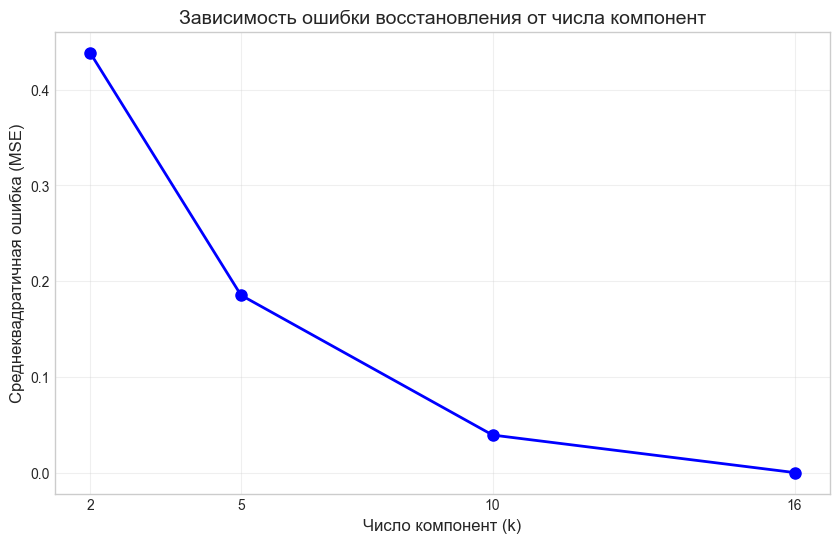

Анализ графика:
Наибольшее снижение ошибки наблюдается при переходе от 2 к 5 компонентам — с 0.495 до 0.175. После 10 компонент ошибка продолжает уменьшаться незначительно, стремясь к нулю. Следовательно, оптимальное число компонент достигается в диапазоне k = 8-10.


In [39]:
k_values = [2, 5, 10, 16]

print(f"Общее количество признаков - {X_std_array.shape[1]}")
print(f"Рассматриваемые k: {k_values}")

mse_results = []

for k in k_values:
    pca = PCA(n_components=k)
    X_projected = pca.fit_transform(X_std_array)
    X_reconstructed = pca.inverse_transform(X_projected)
    mse = np.mean((X_std_array - X_reconstructed) ** 2)
    mse_results.append(mse)

print("\nТаблица")
print("="*50)
print(f"{'Число компонент':<20} {'Ошибка восстановления (MSE)':<30}")
print("-"*50)
for k, mse in zip(k_values, mse_results):
    print(f"{k:<20} {mse:<30.6f}")

plt.figure(figsize=(10, 6))
plt.plot(k_values, mse_results, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Число компонент (k)', fontsize=12)
plt.ylabel('Среднеквадратичная ошибка (MSE)', fontsize=12)
plt.title('Зависимость ошибки восстановления от числа компонент', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(k_values)
plt.show()

print("Анализ графика:")
print("Наибольшее снижение ошибки наблюдается при переходе от 2 к 5 компонентам — с 0.495 до 0.175. После 10 компонент ошибка продолжает уменьшаться незначительно, стремясь к нулю. Следовательно, оптимальное число компонент достигается в диапазоне k = 8-10.")

### 6.5 Интерпретация результатов

**1. Почему при малом числе компонент ошибка восстановления большая?**

При малом k сохраняются только направления наибольшей дисперсии, а остальные отбрасываются. Это приводит к потере части информации, особенно мелких деталей и шумов, которые могут быть важны для точного восстановления.

**2. Почему увеличение числа компонент уменьшает ошибку?**

Каждая дополнительная компонента возвращает часть утерянной информации. Чем больше компонент используется, тем точнее восстановление, так как сохраняется больше исходных измерений.

**3. Можно ли полностью восстановить исходные данные при использовании всех компонент?**

Да. Если взять k равным исходной размерности, PCA становится просто поворотом системы координат без потери информации. В этом случае MSE = 0.

**4. Как это связано с объяснённой дисперсией PCA?**

Ошибка восстановления и объяснённая дисперсия связаны обратной зависимостью: чем больше дисперсии сохранено, тем меньше MSE (MSE = 1 - "накопленная дисперсия").

**5. Как можно определить разумное число компонент, при котором данные уже хорошо описаны, но размерность существенно меньше?**

Существует несколько подходов: метод колена — выбор k в точке излома графика ошибки; пороговый метод — выбор k, объясняющего 90-95% дисперсии. В данном случае оптимальным является k = 8-10, так как при этом достигается хорошее качество восстановления при значительном снижении размерности.

## 7. Итоговый анализ

**1. Какую роль играет снижение размерности в анализе данных?**

Снижение размерности позволяет упростить данные, удалить шум и избыточную информацию, ускорить обучение моделей и визуализировать многомерные данные на плоскости. Это помогает выявить скрытую структуру и закономерности, которые не видны в исходном пространстве признаков.

**2. Всегда ли уменьшение размерности полезно?**

Нет. Уменьшение размерности всегда сопровождается потерей информации. Если данные уже имеют низкую размерность или каждый признак важен для анализа, сжатие может привести к неверным выводам.

**3. В каких случаях линейные методы могут работать хуже нелинейных?**

Линейные методы (PCA) плохо работают, когда данные имеют сложную нелинейную структуру, например, точки образуют сложные нелинейные формы, лежат на изогнутой поверхности. В таких случаях t-SNE и UMAP лучше сохраняют локальную структуру и разделяют кластеры.

**4. Какие преимущества и ограничения есть у методов PCA, t-SNE и UMAP?**

| Метод | Преимущества | Ограничения                                                                              |
|-------|--------------|------------------------------------------------------------------------------------------|
| PCA | Быстрый, сохраняет глобальную структуру, легко интерпретировать компоненты | Только линейные преобразования, плохо разделяет нелинейные кластеры |
| t-SNE | Отлично разделяет кластеры, сохраняет локальную структуру | Медленный, чувствителен к perplexity, не сохраняет глобальные расстояния, стохастический |
| UMAP | Быстрее t-SNE, лучше сохраняет глобальную структуру, меньше чувствителен к параметрам | Сложнее интерпретировать, стохастический |